# Lab 13 — CNN ในงานจริง: dataset จากไฟล์ภาพ, augmentation, early stopping และ transfer learning
### CNNs in practice: custom image Dataset, augmentation inside the DataLoader, early stopping, transfer learning with ResNet-18

**กลุ่ม:** E CNN · **อ่านคู่กับสไลด์หน้า:** 96, 122-125, 203-210 · **เวลาโดยประมาณ:** 120 นาที · **Dataset:** data/cifar3 (bird / dog / frog จาก CIFAR-10, 1,800 ภาพ PNG 32×32)

**ควรทำมาก่อน:** lab12 (LeNet-5, DataLoader, transforms) และ lab08 (early stopping ฝั่ง numpy)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. เขียน `torch.utils.data.Dataset` ที่อ่านภาพจากไฟล์ตามรายการใน CSV และรู้ว่า `DataLoader` ประกอบ batch จากมันอย่างไร
2. แยก transform ของ train (มี augmentation) กับ eval (deterministic) และอธิบายได้ว่าทำไมต้อง normalize ด้วยค่าของ ImageNet
3. เขียน training loop ที่เรียก `model.train()` / `model.eval()` ถูกที่ และเพิ่ม early stopping พร้อม checkpoint ได้
4. ทำ transfer learning 3 ขั้น: freeze backbone ของ ResNet-18 ที่ pretrained → เทรน head ใหม่ → fine-tune block สุดท้ายด้วย learning rate ต่ำ
5. เทียบ CNN จากศูนย์กับ transfer learning ด้วย metric, จำนวน parameter ที่เทรน และเวลา แล้วเลือกได้ว่างานไหนควรใช้แบบไหน

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้ใช้ CPU ล้วนได้ ทั้ง notebook รันประมาณ 1.5-2 นาที (ครั้งแรกต้องดาวน์โหลดน้ำหนัก ResNet-18 ~45 MB)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed

import os, time, copy, tempfile
import pandas as pd
import torch, torchvision
from torch import nn
from torchvision.transforms import v2
torch.manual_seed(463)
FAST = bool(os.environ.get("NNLAB_FAST"))                 # ตั้ง NNLAB_FAST=1 เพื่อรันแบบย่อ (ข้อมูล/epoch น้อยลง)
DEVICE = os.environ.get("NNLAB_DEVICE", "cpu")            # cpu ให้ตัวเลขทำซ้ำได้; mps/cuda เร็วกว่าแต่ทศนิยมต่างเล็กน้อย
print("device:", DEVICE, "| FAST:", FAST, "| torchvision", torchvision.__version__)

rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

device: cpu | FAST: False | torchvision 0.29.0
numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์และคำศัพท์ในบทนี้
| คำ | ความหมาย |
|---|---|
| `Dataset` | object ที่ตอบได้ว่า "มีกี่ตัวอย่าง" (`__len__`) และ "ตัวอย่างที่ i คืออะไร" (`__getitem__`) |
| `DataLoader` | ตัวดึงตัวอย่างจาก Dataset มาประกอบเป็น mini-batch (สับลำดับ, ทำขนานได้) |
| transform | ฟังก์ชันแปลงภาพก่อนเข้าโมเดล: resize, augmentation, แปลง dtype, normalize |
| augmentation | การสุ่มแปลงภาพ train (ตัด, กลับด้าน, หมุน) เพื่อให้โมเดลเห็นภาพไม่ซ้ำและ overfit ยากขึ้น (สไลด์ p.208-210) |
| backbone / head | ส่วนสกัด feature ของ pretrained model / ชั้นสุดท้ายที่ตัดสินใจ class ของโจทย์เรา |
| freeze | ตั้ง `requires_grad = False` ให้ parameter ไม่ถูกอัปเดต |
| fine-tune | ปลด freeze บางชั้นแล้วเทรนต่อด้วย learning rate ต่ำ |
| patience | จำนวน epoch ที่ยอมให้ validation loss ไม่ดีขึ้นก่อนหยุด (early stopping, สไลด์ p.96) |
| checkpoint | ไฟล์ที่บันทึก `state_dict` ของโมเดล ณ จุดที่ดีที่สุด |

## ขั้นที่ 1 · ข้อมูลภาพในงานจริง: โฟลเดอร์ + ไฟล์ทะเบียน (CSV)
lab12 ได้ MNIST มาเป็น tensor สำเร็จรูป แต่ในงานจริงภาพมักเป็น**ไฟล์ในโฟลเดอร์** และมี**ไฟล์ทะเบียน** (CSV) บอกว่าไฟล์ไหนคือ class อะไร อยู่ split ไหน
`data/cifar3/` คือชุดข้อมูลแบบนั้น: ภาพสี 32×32 จาก CIFAR-10 เฉพาะ 3 class (bird, dog, frog) จำนวน train 400 / val 100 / test 100 ต่อ class
สร้างด้วย `scripts/make_image_dataset.py` แล้ว commit ไว้ใน repo (~5 MB) จึงไม่ต้องดาวน์โหลดอะไร
cell นี้ดูโครงสร้างโฟลเดอร์ อ่าน `labels.csv` ด้วย pandas (lab03) แล้วนับภาพต่อ split/class

In [2]:
from nnlab.vision import cifar3_root, read_image_rgb
from nnlab.plotting import show_images

ROOT = cifar3_root()                                              # lab/data/cifar3
print("root:", ROOT)
for split in ["train", "val", "test"]:
    per_class = {d.name: len(list(d.glob("*.png"))) for d in sorted((ROOT / split).iterdir())}
    print(f"  {split:<6}", per_class)

df = pd.read_csv(ROOT / "labels.csv")                             # df: (1800, 3) คอลัมน์ path, label, split
print("\nlabels.csv:", df.shape)
display(df.head())
display(pd.crosstab(df["split"], df["label"], margins=True))

root: /Users/ruccidavinci/Library/CloudStorage/GoogleDrive-ratchainant.tha@gmail.com/My Drive/SWU/VRU-AI/swu-courses/CP463 - Artificial Intelligence/lab/data/cifar3
  train  {'bird': 400, 'dog': 400, 'frog': 400}
  val    {'bird': 100, 'dog': 100, 'frog': 100}
  test   {'bird': 100, 'dog': 100, 'frog': 100}

labels.csv: (1800, 3)


,path,label,split
0,train/bird/00110.png,bird,train
1,train/bird/00325.png,bird,train
2,train/bird/00396.png,bird,train
3,train/bird/00405.png,bird,train
4,train/bird/00475.png,bird,train


label,bird,dog,frog,All
split,,,,
test,100,100,100,300
train,400,400,400,1200
val,100,100,100,300
All,600,600,600,1800


ดูภาพจริงสัก 4 ภาพต่อ class — `read_image_rgb` อ่านไฟล์ PNG เป็น uint8 tensor รูป `(3, H, W)` (channel มาก่อน ตาม convention ของ torch)
ส่วน `show_images` ต้องการ `(H, W, C)` จึง `permute(1, 2, 0)` ก่อน — ภาพ 32×32 เล็กและเบลอ แต่มนุษย์ยังแยก นก / หมา / กบ ได้

ภาพแรก shape (32, 32, 3) dtype uint8 ค่า pixel 16 - 247


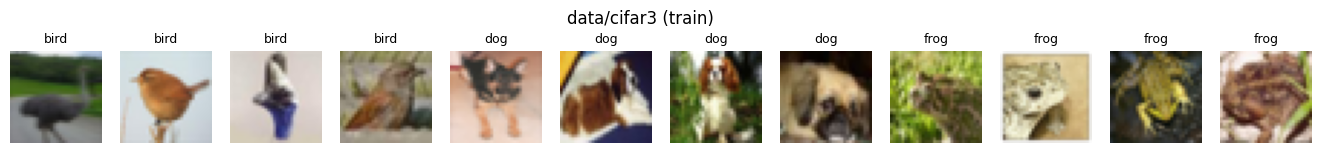

In [3]:
sample_rows = df[df["split"] == "train"].groupby("label").head(4)             # 4 ภาพแรกของแต่ละ class
imgs = [read_image_rgb(ROOT / p).permute(1, 2, 0).numpy() for p in sample_rows["path"]]   # แต่ละภาพ: (32, 32, 3) uint8
print("ภาพแรก shape", imgs[0].shape, "dtype", imgs[0].dtype, "ค่า pixel", imgs[0].min(), "-", imgs[0].max())
show_images(np.stack(imgs), sample_rows["label"].tolist(), n=12, title="data/cifar3 (train)")
plt.show()

## ขั้นที่ 2 · เขียน `Dataset` เองทีละบรรทัด
`torch.utils.data.Dataset` เป็นสัญญา (interface) ง่ายๆ: class ต้องมี `__len__` (มีกี่ตัวอย่าง) และ `__getitem__(i)` (ตัวอย่างที่ i) เท่านั้น
`DataLoader` จะสุ่ม index แล้วเรียก `__getitem__` ทีละตัวมาประกอบเป็น batch ให้เอง — เราจึง**ไม่ต้องโหลดภาพทั้งหมดเข้า memory** อ่านจาก disk เฉพาะตอนถูกเรียก
สิ่งที่ `__getitem__` ต้องคืน: `(ภาพที่ผ่าน transform แล้ว, label เป็นเลข class index)` — `CrossEntropyLoss` ต้องการ index ไม่ใช่ one-hot (lab12)
cell นี้เขียนเวอร์ชันสั้นที่สุด: อ่าน CSV ครั้งเดียวใน `__init__` แล้วเก็บ list ของ path กับ label ไว้

In [4]:
class MyImageDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path, split, transform=None):
        table = pd.read_csv(csv_path)
        table = table[table["split"] == split]                       # เลือกเฉพาะ split ที่ต้องการ
        self.root = csv_path.parent
        self.classes = sorted(table["label"].unique())                # ['bird', 'dog', 'frog']
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.paths = [self.root / p for p in table["path"]]           # list ของ path (ยังไม่อ่านภาพ)
        self.targets = [self.class_to_idx[l] for l in table["label"]] # label เป็น class index
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = read_image_rgb(self.paths[i])                           # อ่านจาก disk ตอนถูกเรียกเท่านั้น: uint8 (3, 32, 32)
        if self.transform is not None:
            img = self.transform(img)                                 # augmentation สุ่มใหม่ทุกครั้งที่ถูกเรียก
        return img, self.targets[i]

ds_train_raw = MyImageDataset(ROOT / "labels.csv", "train")
img0, y0 = ds_train_raw[0]
print("len =", len(ds_train_raw), "| class_to_idx =", ds_train_raw.class_to_idx)
print("ds[0] → image", tuple(img0.shape), img0.dtype, "| label", y0, "=", ds_train_raw.classes[y0])

len = 1200 | class_to_idx = {'bird': 0, 'dog': 1, 'frog': 2}
ds[0] → image (3, 32, 32) torch.uint8 | label 0 = bird


สามข้อที่มักเขียนผิดใน `Dataset` (พบใน tutorial รุ่นเก่าๆ รวมทั้งของผู้สอนเอง):
1. คำนวณอะไรกับ**ทั้งตาราง**ใน `__getitem__` (เช่น one-hot ทุกแถว) → ช้าลง N เท่าโดยไม่รู้ตัว — ทำใน `__init__` ครั้งเดียว
2. คืน label เป็น one-hot → ต้อง argmax กลับตอนวัดผล และเปลือง memory — ใช้ class index
3. ใส่ augmentation ใน Dataset เดียวแล้วใช้กับ val/test ด้วย → คะแนน test แกว่งทุกครั้งที่วัด — แยก transform (ขั้นที่ 3)

`nnlab.vision.ImageCSVDataset` คือเวอร์ชันเต็ม (ตรวจ split, รับ `class_to_idx` ร่วมกัน, มี `counts()`); cell นี้ยืนยันว่าให้ผลเหมือนของเรา

In [5]:
from nnlab.vision import ImageCSVDataset

ds_lib = ImageCSVDataset(ROOT / "labels.csv", split="train")
print(ds_lib)
print("counts:", ds_lib.counts())
assert len(ds_lib) == len(ds_train_raw) and ds_lib.class_to_idx == ds_train_raw.class_to_idx
assert torch.equal(ds_lib[0][0], img0) and ds_lib[0][1] == y0
print("ตรงกับที่เขียนเอง ✓")

ImageCSVDataset(split='train', n=1200, classes=['bird', 'dog', 'frog'], root=/Users/ruccidavinci/Library/CloudStorage/GoogleDrive-ratchainant.tha@gmail.com/My Drive/SWU/VRU-AI/swu-courses/CP463 - Artificial Intelligence/lab/data/cifar3)
counts: {'bird': 400, 'dog': 400, 'frog': 400}
ตรงกับที่เขียนเอง ✓


## ขั้นที่ 3 · transform ของ train กับ eval ต้องต่างกัน
ภาพ uint8 0-255 ต้องผ่าน 3 อย่างก่อนเข้าโมเดล: (1) ปรับขนาด (2) แปลงเป็น float ช่วง [0, 1] (3) **normalize** ให้แต่ละ channel มี mean/std มาตรฐาน
ค่า mean/std ที่ใช้คือของ **ImageNet** `(0.485, 0.456, 0.406)` / `(0.229, 0.224, 0.225)` — ไม่ใช่เพราะข้อมูลเราเป็นแบบนั้น แต่เพราะ pretrained model ในขั้นที่ 7 ถูกเทรนด้วยภาพที่ normalize แบบนี้ ถ้าเราป้อนภาพคนละ scale feature ที่มันเรียนมาจะเพี้ยน
**train** เพิ่ม augmentation ก่อนแปลง float: `RandomCrop` (เติมขอบแล้วตัดสุ่ม = เลื่อนภาพ, p.209) และ `RandomHorizontalFlip` (p.208 — กลับซ้ายขวาได้เพราะนกกลับด้านยังเป็นนก ต่างจากตัวเลขใน lab12)
**eval** (val/test) ไม่มีการสุ่มเลย → วัดผลได้ค่าเดิมทุกครั้ง
ที่นี่ใช้ `torchvision.transforms.v2` ซึ่งทำงานบน tensor โดยตรง (lab12 ใช้ v1 ที่ยังใช้ได้เหมือนกัน)

Compose(
      Resize(size=[32], interpolation=bilinear, antialias=True)
      RandomCrop(size=(32, 32), padding=[4, 4, 4, 4], pad_if_needed=False, fill=0, padding_mode=constant)
      RandomHorizontalFlip(p=0.5)
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

หลัง eval transform: (3, 32, 32) torch.float32 | ช่วงค่า -1.83 ถึง 2.50 (ไม่ใช่ 0-1 แล้ว)


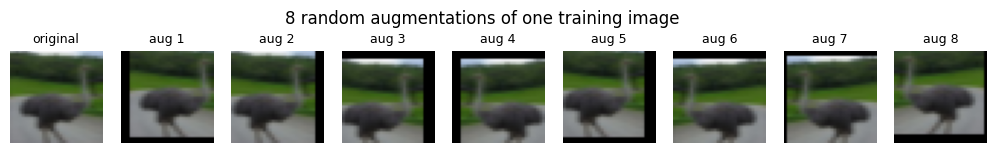

In [6]:
from nnlab.vision import IMAGENET_MEAN, IMAGENET_STD, make_transforms, denormalize

train_tf = make_transforms(train=True, size=32)      # Resize → RandomCrop(pad 4) → RandomHorizontalFlip → ToDtype(float, scale) → Normalize
eval_tf = make_transforms(train=False, size=32)      # Resize → ToDtype → Normalize
print(train_tf)

x = eval_tf(img0)                                    # x: (3, 32, 32) float32 ที่ normalize แล้ว
print("\nหลัง eval transform:", tuple(x.shape), x.dtype, "| ช่วงค่า %.2f ถึง %.2f (ไม่ใช่ 0-1 แล้ว)" % (x.min(), x.max()))
assert torch.equal(eval_tf(img0), eval_tf(img0)), "eval transform ต้อง deterministic"
assert not torch.equal(train_tf(img0), train_tf(img0)), "train transform ต้องสุ่ม"

torch.manual_seed(463)
augmented = torch.stack([denormalize(train_tf(img0)) for _ in range(8)])          # denormalize เพื่อเอามาดู
show_images(np.concatenate([img0.permute(1, 2, 0).numpy()[None] / 255.0, augmented.permute(0, 2, 3, 1).numpy()]),
            ["original"] + [f"aug {k + 1}" for k in range(8)], n=9, title="8 random augmentations of one training image")
plt.show()

เช็คสั้นๆ ว่า mean/std ของ cifar3 ต่างจากค่า ImageNet แค่ไหน — ต่างเล็กน้อยแต่ไม่เป็นไร: สิ่งสำคัญคือใช้**ชุดเดียวกับที่ pretrained model เห็นตอนเทรน** (ถ้าเทรนจากศูนย์จะใช้ค่าของข้อมูลตัวเองก็ได้)

In [7]:
stack = torch.stack([read_image_rgb(p).float() / 255 for p in ds_lib.paths[:300]])   # stack: (300, 3, 32, 32)
print("cifar3 mean per channel:", stack.mean(dim=(0, 2, 3)).numpy().round(3), " std:", stack.std(dim=(0, 2, 3)).numpy().round(3))
print("ImageNet mean          :", np.round(IMAGENET_MEAN, 3), " std:", np.round(IMAGENET_STD, 3))

cifar3 mean per channel: [0.484 0.488 0.418]  std: [0.224 0.221 0.245]
ImageNet mean          : [0.485 0.456 0.406]  std: [0.229 0.224 0.225]


## ขั้นที่ 4 · `DataLoader` สามชุด
`load_cifar3_loaders` สร้าง Dataset 3 ชุดจาก CSV เดียว (train ใช้ train transform, val/test ใช้ eval transform) แล้วห่อด้วย `DataLoader`
- train: `shuffle=True` + `generator` ที่ตั้ง seed → ลำดับ batch ทำซ้ำได้; val/test ไม่ต้องสับ
- `num_workers=0` (อ่านภาพใน process หลัก) — ใน notebook บน macOS/Windows การเปิด worker หลายตัวมักค้างเพราะใช้ spawn; ใน script ค่อยเปิด `--num-workers`
- `fast=FAST` ลด train เหลือ 100 ภาพ/class เมื่อรันแบบย่อ
เริ่มที่ขนาด 32 px (ต้นฉบับ) สำหรับ CNN จากศูนย์ ส่วน ResNet-18 จะใช้ 64 px ในขั้นที่ 7

In [8]:
from nnlab.vision import load_cifar3_loaders

train32, val32, test32, classes = load_cifar3_loaders(batch_size=64, size=32, augment=True, fast=FAST, num_workers=0)
print("classes:", classes, "| train", len(train32.dataset), "| val", len(val32.dataset), "| test", len(test32.dataset))
xb, yb = next(iter(train32))                                  # xb: (64, 3, 32, 32) float32 | yb: (64,) int64
print("batch:", tuple(xb.shape), xb.dtype, "| labels:", tuple(yb.shape), yb.dtype, "| batch ต่อ epoch:", len(train32))
print("label ใน batch แรก:", np.bincount(yb.numpy(), minlength=3), "(นับต่อ class — สับแล้วจึงคละกัน)")

classes: ['bird', 'dog', 'frog'] | train 1200 | val 300 | test 300
batch: (64, 3, 32, 32) torch.float32 | labels: (64,) torch.int64 | batch ต่อ epoch: 19
label ใน batch แรก: [16 24 24] (นับต่อ class — สับแล้วจึงคละกัน)


## ขั้นที่ 5 · CNN เล็กจากศูนย์ กับ training loop ที่ถูกต้อง
`SmallCNN`: 3 block ของ (conv 3×3 → BatchNorm → ReLU → MaxPool) ตามด้วย `AdaptiveAvgPool2d(4)` (ทำให้รับภาพขนาดใดก็ได้) → Dropout → Linear
เขียน loop เองอีกครั้ง (เหมือน lab12) แต่คราวนี้เน้น**สองบรรทัดที่ลืมบ่อยที่สุด**:
- `model.train()` ที่ต้นทุก epoch — เปิด dropout และให้ BatchNorm ใช้สถิติของ batch
- `model.eval()` + `torch.inference_mode()` ตอนวัด val — ปิด dropout, BatchNorm ใช้ running stats, ไม่เก็บ gradient

ถ้าเรียก `model.eval()` ตอนวัดผลแล้ว**ไม่**เรียก `model.train()` กลับ (bug ที่พบใน notebook รุ่นเก่าของผู้สอน) dropout จะปิดตลอดการเทรนตั้งแต่ epoch ที่ 2 โดยไม่มี error ใดๆ

In [9]:
from nnlab.vision import SmallCNN
from nnlab.torch_models import count_parameters, TorchTrainer

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()                                              # ← สำคัญ: เปิด dropout / BN mode เทรน ทุก epoch
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb); n += len(xb)
    return total / n

@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval()                                               # ← ปิด dropout, BN ใช้ running stats
    total, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        total += criterion(out, yb).item() * len(xb)
        correct += (out.argmax(dim=1) == yb).sum().item(); n += len(xb)
    return total / n, correct / n

torch.manual_seed(463)
small = SmallCNN(n_classes=3).to(DEVICE)
print("SmallCNN parameters:", f"{count_parameters(small):,}")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(small.parameters(), lr=1e-3)
EPOCHS = 3 if FAST else 12
hist = {"train": [], "val": [], "val_acc": []}
t0 = time.perf_counter()
for epoch in range(EPOCHS):
    tr = train_one_epoch(small, train32, optimizer, criterion)
    va, acc = evaluate(small, val32, criterion)
    hist["train"].append(tr); hist["val"].append(va); hist["val_acc"].append(acc)
    print(f"epoch {epoch:2d}  train {tr:.3f}  val {va:.3f}  val_acc {acc:.3f}")
small_seconds = time.perf_counter() - t0
small_metrics = TorchTrainer(small, loss="ce", device=DEVICE).evaluate_loader(test32)      # ใช้ metrics ของ nnlab (accuracy, macro F1)
small_test_acc = small_metrics["accuracy"]
print(f"\nSmallCNN: {small_seconds:.1f} s | test accuracy {small_test_acc:.3f} | macro F1 {small_metrics['macro_f1']:.3f}")

SmallCNN parameters: 26,883


epoch  0  train 1.066  val 0.961  val_acc 0.540


epoch  1  train 0.940  val 0.874  val_acc 0.603


epoch  2  train 0.836  val 0.779  val_acc 0.660


epoch  3  train 0.804  val 0.731  val_acc 0.663


...

epoch  7  train 0.717  val 0.709  val_acc 0.707


epoch  8  train 0.648  val 0.673  val_acc 0.693


epoch  9  train 0.644  val 0.703  val_acc 0.697


epoch 10  train 0.653  val 0.693  val_acc 0.710


epoch 11  train 0.603  val 0.724  val_acc 0.693

SmallCNN: 6.9 s | test accuracy 0.727 | macro F1 0.728


วาด train/val cost คู่กัน: ข้อมูล train มีแค่ 1,200 ภาพ (หรือ 300 เมื่อ FAST) โมเดลจึงเริ่มจำข้อมูลได้ไม่นาน — train cost ลงต่อเนื่องแต่ val cost หยุดลงหรือกลับขึ้น นี่คือ overfitting ที่เห็นใน lab08 และเป็นเหตุผลของ early stopping ในขั้นถัดไป
ส่วน LeNet-5 จาก lab12 (ปรับรับภาพสี 3 channel, ไม่ต้อง pad เพราะภาพ 32×32 แล้ว) เทรนผ่าน `TorchTrainer` ไว้เป็น baseline อีกตัว

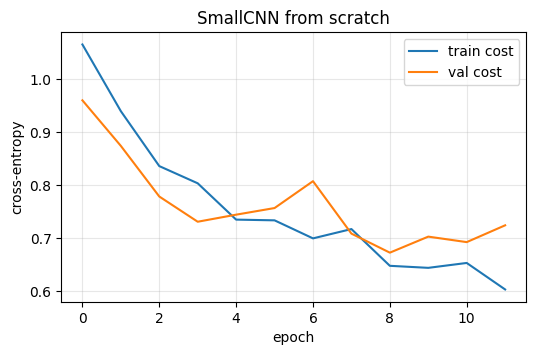

LeNet-5 (3 channel): 4.1 s | test accuracy 0.673 | parameters 61,411


In [10]:
from nnlab.torch_models import LeNet5, TorchTrainer

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hist["train"], label="train cost"); ax.plot(hist["val"], label="val cost")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy"); ax.set_title("SmallCNN from scratch"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

torch.manual_seed(463)
lenet_trainer = TorchTrainer(LeNet5(n_classes=3, in_channels=3, pad=0), loss="ce", optimizer="adam", lr=1e-3, epochs=EPOCHS, device=DEVICE)
t0 = time.perf_counter(); lenet_trainer.fit_loader(train32, val32); lenet_seconds = time.perf_counter() - t0
lenet_metrics = lenet_trainer.evaluate_loader(test32)
print(f"LeNet-5 (3 channel): {lenet_seconds:.1f} s | test accuracy {lenet_metrics['accuracy']:.3f} | parameters {count_parameters(lenet_trainer.model):,}")

## ขั้นที่ 6 · early stopping (สไลด์ p.96)
ใน lab08 เราทำ early stopping กับ network ฝั่ง numpy: ดู val cost ทุก epoch, จำน้ำหนัก ณ epoch ที่ดีที่สุด, ถ้าไม่ดีขึ้นติดกัน `patience` epoch ให้หยุดแล้วคืนน้ำหนักที่ดีที่สุด
ฝั่ง torch ต่างแค่วิธีจำน้ำหนัก: `model.state_dict()` คือ dict ของ tensor ทุกตัว ต้อง `copy.deepcopy` (หรือ `clone`) ไม่งั้นได้แค่ reference ที่เปลี่ยนตามการเทรน
cell นี้เขียน loop เองบน `SmallCNN` ตัวใหม่: patience 4, สูงสุด 25 epoch (FAST: 8)

early stopping ที่ epoch 10 (ดีที่สุด epoch 6, val 0.675)
epoch ที่รัน 11 / 25 | test accuracy หลัง restore 0.750


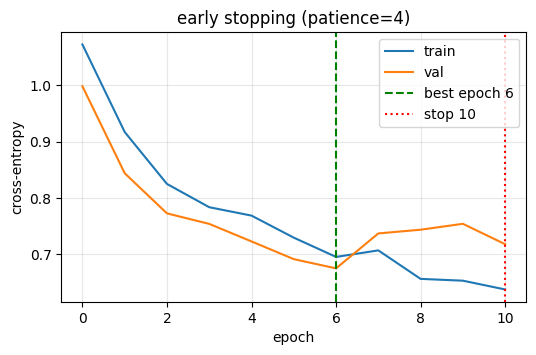

In [11]:
torch.manual_seed(463)
model_es = SmallCNN(n_classes=3).to(DEVICE)
optimizer = torch.optim.Adam(model_es.parameters(), lr=1e-3)
PATIENCE, MAX_EPOCHS = 4, (8 if FAST else 25)
best_val, best_epoch, wait, best_state = float("inf"), -1, 0, None
val_curve, train_curve = [], []
for epoch in range(MAX_EPOCHS):
    train_curve.append(train_one_epoch(model_es, train32, optimizer, criterion))
    va, acc = evaluate(model_es, val32, criterion)
    val_curve.append(va)
    if va < best_val - 1e-6:                                   # ดีขึ้น → จำไว้ + reset ตัวนับ
        best_val, best_epoch, wait = va, epoch, 0
        best_state = copy.deepcopy(model_es.state_dict())      # ต้อง copy จริงๆ ไม่ใช่ reference
    else:
        wait += 1
        if wait >= PATIENCE:                                   # ไม่ดีขึ้นติดกันครบ patience → หยุด
            print(f"early stopping ที่ epoch {epoch} (ดีที่สุด epoch {best_epoch}, val {best_val:.3f})")
            break
model_es.load_state_dict(best_state)                           # คืนน้ำหนักที่ดีที่สุด
stopped_epoch = epoch
_, es_test_acc = evaluate(model_es, test32, criterion)
print(f"epoch ที่รัน {len(val_curve)} / {MAX_EPOCHS} | test accuracy หลัง restore {es_test_acc:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(train_curve, label="train"); ax.plot(val_curve, label="val")
ax.axvline(best_epoch, color="g", ls="--", label=f"best epoch {best_epoch}"); ax.axvline(stopped_epoch, color="r", ls=":", label=f"stop {stopped_epoch}")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy"); ax.set_title(f"early stopping (patience={PATIENCE})"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

โค้ดเดียวกันถูกจัดเป็น `nnlab.torch_models.EarlyStopping` (เรียก `step(val_loss, model)` ทุก epoch คืน `True` เมื่อควรหยุด และบันทึก checkpoint ให้ถ้าระบุ path)
และ `TorchTrainer(early_stopping_patience=...)` ใช้มันให้อัตโนมัติ — semantics เดียวกับ `NeuralNetwork` ใน lab08: `stopped_epoch_ == best_epoch_ + patience`
cell นี้ใช้กับ LeNet-5 พร้อมเขียน checkpoint ลงโฟลเดอร์ชั่วคราว แล้วโหลดกลับมาดูว่าข้างในมีอะไร

In [12]:
from nnlab.torch_models import EarlyStopping

tmpdir = tempfile.mkdtemp()
torch.manual_seed(463)
lenet_es = TorchTrainer(LeNet5(n_classes=3, in_channels=3, pad=0), loss="ce", optimizer="adam", lr=1e-3, epochs=(10 if FAST else 40),
                        early_stopping_patience=4, checkpoint_path=f"{tmpdir}/lenet_best.pt", device=DEVICE, verbose=True, log_every=5)
lenet_es.fit_loader(train32, val32)
val = np.array(lenet_es.history_["val_cost"])
print("\nstopped_epoch_ =", lenet_es.stopped_epoch_, "| best_epoch_ =", lenet_es.best_epoch_, "| argmin(val) =", int(val.argmin()))
if lenet_es.stopped_epoch_ is not None:
    assert lenet_es.stopped_epoch_ == int(val.argmin()) + 4 == lenet_es.best_epoch_ + 4
ckpt = torch.load(f"{tmpdir}/lenet_best.pt", weights_only=False)
print("checkpoint keys:", list(ckpt), "| epoch", ckpt["epoch"], "| val_loss %.4f" % ckpt["val_loss"], "| state_dict tensors:", len(ckpt["state_dict"]))
lenet_es_metrics = lenet_es.evaluate_loader(test32)
print("LeNet-5 + early stopping: test accuracy %.3f" % lenet_es_metrics["accuracy"])

epoch    0  cost 1.0498  val_cost 0.9856  val_acc 0.4833


epoch    5  cost 0.8484  val_cost 0.8149  val_acc 0.6100


epoch   10  cost 0.7610  val_cost 0.7965  val_acc 0.6433


epoch   15  cost 0.7078  val_cost 0.6648  val_acc 0.7100


epoch   20  cost 0.6844  val_cost 0.6707  val_acc 0.7267


epoch   25  cost 0.6358  val_cost 0.6581  val_acc 0.7200


epoch   30  cost 0.6028  val_cost 0.6575  val_acc 0.7267


early stopping ที่ epoch 33 (best epoch 29, val_cost 0.6137) — คืนน้ำหนักที่ดีที่สุด

stopped_epoch_ = 33 | best_epoch_ = 29 | argmin(val) = 29
checkpoint keys: ['state_dict', 'epoch', 'val_loss'] | epoch 29 | val_loss 0.6137 | state_dict tensors: 10
LeNet-5 + early stopping: test accuracy 0.737


## ขั้นที่ 7 · transfer learning ด้วย ResNet-18 (สไลด์ p.203-207)
โมเดลใหญ่อย่าง ResNet ถูกเทรนบน ImageNet (1.2 ล้านภาพ 1,000 class) ชั้นต้นๆ เรียนรู้ feature ทั่วไป (ขอบ, ลาย, รูปทรง) ที่ใช้ได้กับภาพแทบทุกชนิด
**transfer learning** คือเอาน้ำหนักเหล่านั้นมาใช้ต่อ แทนที่จะเริ่มจากศูนย์ด้วยข้อมูลแค่ 1,200 ภาพ — ทำ 3 ขั้น:
1. **freeze** backbone ทั้งหมด แล้วแทน head 1000 class ด้วย head ใหม่ 3 class
2. **เทรน head** อย่างเดียว (backbone เป็น feature extractor คงที่)
3. **fine-tune**: ปลด freeze block สุดท้าย (`layer4`) แล้วเทรนต่อด้วย learning rate ต่ำ

### (a) โหลด pretrained ResNet-18
`torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)` ดาวน์โหลดน้ำหนัก 45 MB ครั้งแรกไปที่ cache ของ torch แล้วใช้ซ้ำได้ตลอด (lab12 ใช้ `weights=None` = สุ่ม)
object `weights` บอกด้วยว่าโมเดลคาดหวังภาพแบบไหน (`transforms()`) และทำได้ดีแค่ไหนบน ImageNet

In [13]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
net = resnet18(weights=weights)                                   # ดาวน์โหลดครั้งแรก ~45 MB
print("cache:", torch.hub.get_dir())
print("ImageNet acc@1 ของน้ำหนักนี้:", weights.meta["_metrics"]["ImageNet-1K"]["acc@1"], "%")
print("ตัวอย่าง class ของ ImageNet:", weights.meta["categories"][:3], "...", weights.meta["categories"][-2:])
print("transform ที่โมเดลคาดหวัง:", weights.transforms())
print("\nhead เดิม:", net.fc, "| parameter ทั้งหมด", f"{count_parameters(net, trainable_only=False):,}", "| เทรนได้", f"{count_parameters(net):,}")

cache: /Users/ruccidavinci/.cache/torch/hub
ImageNet acc@1 ของน้ำหนักนี้: 69.758 %
ตัวอย่าง class ของ ImageNet: ['tench', 'goldfish', 'great white shark'] ... ['ear', 'toilet tissue']
transform ที่โมเดลคาดหวัง: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

head เดิม: Linear(in_features=512, out_features=1000, bias=True) | parameter ทั้งหมด 11,689,512 | เทรนได้ 11,689,512


### (b) freeze backbone แล้วแทน head
`requires_grad = False` บอก autograd ว่าไม่ต้องคำนวณ gradient ของ parameter นั้น → optimizer จะไม่อัปเดตมัน
จากนั้นแทน `net.fc` (Linear 512 → 1000) ด้วย `Linear(512, 3)` ตัวใหม่ (สุ่ม) — parameter ที่เทรนได้จะเหลือแค่ 512×3 + 3 = 1,539 ตัว จาก 11 ล้าน

In [14]:
for p in net.parameters():
    p.requires_grad = False                                       # freeze ทุกอย่าง
net.fc = nn.Linear(512, 3)                                        # head ใหม่ (requires_grad=True โดย default)
print("parameter ทั้งหมด", f"{count_parameters(net, trainable_only=False):,}", "| เทรนได้", f"{count_parameters(net):,}")
print("layer4 conv1 requires_grad:", net.layer4[0].conv1.weight.requires_grad, "| fc requires_grad:", net.fc.weight.requires_grad)

parameter ทั้งหมด 11,178,051 | เทรนได้ 1,539
layer4 conv1 requires_grad: False | fc requires_grad: True


### กับดัก BatchNorm ที่ `requires_grad=False` ไม่ครอบคลุม
BatchNorm มี "running mean/var" ที่**ไม่ใช่ parameter** — มันถูกอัปเดตทุกครั้งที่โมเดลอยู่ใน train mode และเห็นข้อมูล ไม่เกี่ยวกับ gradient เลย
ถ้า `net.train()` แล้วป้อนภาพของเรา สถิติของ ImageNet ที่ backbone จำไว้จะค่อยๆ ถูกแทนด้วยสถิติของ 1,200 ภาพ (เสียงดังกว่ามาก) ทั้งที่เราตั้งใจ "แช่แข็ง"
cell นี้พิสูจน์ด้วยการดู `running_mean` ของ BN ตัวแรกก่อน/หลังป้อน 1 batch แล้วดูว่า `nnlab.vision.TransferResNet18` แก้อย่างไร (override `train()` ให้ BN ที่ freeze อยู่ใน eval เสมอ)

In [15]:
from nnlab.vision import build_resnet18_transfer, format_trainable_table

train64, val64, test64, _ = load_cifar3_loaders(batch_size=64, size=64, augment=True, fast=FAST, num_workers=0)   # 64 px สำหรับ ResNet
xb64, yb64 = next(iter(train64))

net.train()
before = net.bn1.running_mean.clone()
with torch.no_grad():
    net(xb64)
print("resnet18 ธรรมดา: bn1.training =", net.bn1.training, "| running_mean เปลี่ยนหลัง 1 batch:", not torch.equal(before, net.bn1.running_mean))

model = build_resnet18_transfer(n_classes=3, freeze=True, weights="DEFAULT").to(DEVICE)   # backbone + fc ใหม่ + freeze
model.train()
before = model.backbone.bn1.running_mean.clone()
with torch.no_grad():
    model(xb64.to(DEVICE))
print("TransferResNet18: bn1.training =", model.backbone.bn1.training, "| running_mean เปลี่ยน:", not torch.equal(before, model.backbone.bn1.running_mean))
print()
print(format_trainable_table(model))

resnet18 ธรรมดา: bn1.training = True | running_mean เปลี่ยนหลัง 1 batch: True


TransferResNet18: bn1.training = False | running_mean เปลี่ยน: False

module                  parameters  trainable
backbone.conv1               9,408  no
backbone.bn1                   128  no
backbone.layer1            147,968  no
backbone.layer2            525,568  no
backbone.layer3          2,099,712  no
backbone.layer4          8,393,728  no
fc                           1,539  yes
รวม                     11,178,051  trainable 1,539 (0.01%)


### (c) เทรน head — backbone ที่แช่แข็งคือ feature extractor
เมื่อ backbone ไม่เปลี่ยนเลย output 512 มิติของมันสำหรับแต่ละภาพก็**คงที่** → คำนวณครั้งเดียวเก็บไว้ (`extract_features`) แล้วเทรน `Linear(512, 3)` บน feature เหล่านั้นเหมือน logistic regression ใน lab06
เร็วกว่าการผ่าน backbone ซ้ำทุก epoch หลายสิบเท่า (feature ของ train ใช้ภาพที่**ไม่** augment เพื่อให้แต่ละภาพมี feature เดียวที่แน่นอน)
เทรนด้วย `TorchTrainer` + early stopping แล้ว copy น้ำหนักที่ได้เข้า `model.fc`

In [16]:
from nnlab.vision import extract_features

plain_train64, _, _, _ = load_cifar3_loaders(batch_size=64, size=64, augment=False, fast=FAST, num_workers=0)
t0 = time.perf_counter()
F_tr, y_tr = extract_features(model, plain_train64, DEVICE)        # F_tr: (1200, 512) | y_tr: (1200,)
F_va, y_va = extract_features(model, val64, DEVICE)
F_te, y_te = extract_features(model, test64, DEVICE)
feat_seconds = time.perf_counter() - t0
print("features:", tuple(F_tr.shape), tuple(F_va.shape), tuple(F_te.shape), f"| {feat_seconds:.1f} s")

torch.manual_seed(463)
head = TorchTrainer(nn.Linear(512, 3), loss="ce", optimizer="adam", lr=1e-3, epochs=(20 if FAST else 50), batch_size=64,
                    early_stopping_patience=5, device=DEVICE)
t0 = time.perf_counter(); head.fit(F_tr.numpy(), y_tr.numpy(), F_va.numpy(), y_va.numpy()); head_seconds = time.perf_counter() - t0
print(f"head: {len(head.history_['cost'])} epoch ใน {head_seconds:.2f} s | val acc {head.history_['val_acc'][-1]:.3f} | stopped_epoch {head.stopped_epoch_}")

with torch.no_grad():                                              # ย้ายน้ำหนัก head เข้าโมเดลเต็ม
    model.fc.weight.copy_(head.model.weight.cpu()); model.fc.bias.copy_(head.model.bias.cpu())
model.eval()
with torch.inference_mode():
    assert torch.allclose(model(xb64.to(DEVICE)).cpu(), head.model(model.features(xb64.to(DEVICE))).cpu(), atol=1e-4)
head_only = TorchTrainer(model, loss="ce", device=DEVICE)
head_metrics = head_only.evaluate_loader(test64)
head_seconds_total = feat_seconds + head_seconds
print(f"head-only บน test: accuracy {head_metrics['accuracy']:.3f}  macro F1 {head_metrics['macro_f1']:.3f}")

features: (1200, 512) (300, 512) (300, 512) | 7.4 s
head: 13 epoch ใน 0.07 s | val acc 0.863 | stopped_epoch 12


head-only บน test: accuracy 0.833  macro F1 0.833


### (d) fine-tune block สุดท้าย
feature ชั้นท้ายของ ImageNet เฉพาะเจาะจงกับ 1,000 class เดิม การปลด freeze `layer4` ให้ปรับตัวเข้ากับ นก/หมา/กบ **อาจ**ได้ accuracy เพิ่ม — เมื่อข้อมูลมากพอ
กติกา: learning rate ของ backbone ต้อง**ต่ำกว่า** head มาก (ที่นี่ 1e-4 vs 1e-3) ไม่งั้นน้ำหนักดีๆ ที่ยืมมาจะถูกทำลายในไม่กี่ step — ใช้ `param_groups` สร้าง optimizer ที่มี lr สองค่า แล้วส่ง optimizer นั้นให้ `TorchTrainer`
ตอนนี้ต้องผ่าน backbone ทุก epoch (feature ของ layer4 เปลี่ยน) จึงช้ากว่าขั้น (c) ~10 เท่า แต่ใช้ภาพที่ augment ได้เต็มที่ และมี early stopping คุม
สังเกตผลให้ดี: กับข้อมูลแค่ 1,200 ภาพขนาด 32 px การปลด parameter 8.4 ล้านตัวมักได้ผล**ใกล้เคียงหรือต่ำกว่า** head-only เล็กน้อย — parameter มากกว่าข้อมูลหลายพันเท่า และ test set 300 ภาพมีความคลาดเคลื่อน ±3% อยู่แล้ว

In [17]:
from nnlab.vision import unfreeze_layer4, param_groups

unfreeze_layer4(model)
print(format_trainable_table(model))
opt = torch.optim.Adam(param_groups(model, lr_backbone=1e-4, lr_head=1e-3))
print("\noptimizer param groups:", [(len(g["params"]), g["lr"]) for g in opt.param_groups])

torch.manual_seed(463)
finetune = TorchTrainer(model, loss="ce", optimizer=opt, epochs=(1 if FAST else 3), early_stopping_patience=2, device=DEVICE, verbose=True, log_every=1)
t0 = time.perf_counter(); finetune.fit_loader(train64, val64); ft_seconds = time.perf_counter() - t0
ft_metrics = finetune.evaluate_loader(test64)
print(f"\nfine-tuned บน test: accuracy {ft_metrics['accuracy']:.3f}  macro F1 {ft_metrics['macro_f1']:.3f}  ({ft_seconds:.1f} s)")

module                  parameters  trainable
backbone.conv1               9,408  no
backbone.bn1                   128  no
backbone.layer1            147,968  no
backbone.layer2            525,568  no
backbone.layer3          2,099,712  no
backbone.layer4          8,393,728  yes
fc                           1,539  yes
รวม                     11,178,051  trainable 8,395,267 (75.10%)

optimizer param groups: [(15, 0.0001), (2, 0.001)]


epoch    0  cost 0.5791  val_cost 0.4480  val_acc 0.8400


epoch    1  cost 0.4563  val_cost 0.3958  val_acc 0.8567


epoch    2  cost 0.3465  val_cost 0.4084  val_acc 0.8600



fine-tuned บน test: accuracy 0.823  macro F1 0.824  (33.9 s)


## ขั้นที่ 8 · เทียบผลทั้งหมด
ตารางเดียวกันกับที่วิศวกรใช้ตัดสินใจจริง: accuracy / F1 บน test, จำนวน parameter ที่ต้องเทรน, และเวลา
สองบทเรียนจากตาราง:
- head-only เทรน parameter แค่ 1,539 ตัวใน ~10 วินาที แต่ชนะ CNN จากศูนย์ขาดลอย เพราะ feature ที่ยืมมาจาก ImageNet ดีกว่าที่เรียนเองจาก 1,200 ภาพ
- fine-tune ใช้เวลามากกว่าหลายเท่าแต่ได้ผลใกล้เคียง head-only (ต่างกันในระดับ noise ของ test 300 ภาพ) — "เทรนมากขึ้น" ไม่ได้แปลว่า "ดีขึ้น" เสมอ ต้องดู validation และต้นทุนเวลาประกอบ; fine-tune จะคุ้มเมื่อข้อมูลมากขึ้นหรือโจทย์ต่างจาก ImageNet มาก (เช่น ภาพทางการแพทย์)

,test acc,macro F1,trainable,total,seconds
model,,,,,
LeNet-5 (scratch),0.673,0.668,61411,61411,4.069
SmallCNN (scratch),0.727,0.728,26883,26883,6.851
ResNet-18 head only,0.833,0.833,1539,11178051,7.491
ResNet-18 fine-tuned,0.823,0.824,8395267,11178051,41.438


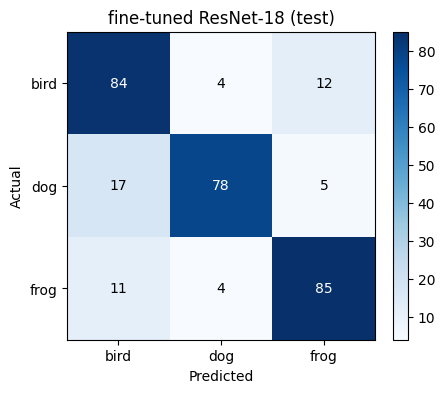

In [18]:
from nnlab.metrics import confusion_matrix
from nnlab.plotting import plot_confusion

results = pd.DataFrame([
    {"model": "LeNet-5 (scratch)",        "test acc": lenet_metrics["accuracy"],    "macro F1": lenet_metrics["macro_f1"],    "trainable": count_parameters(lenet_trainer.model), "total": count_parameters(lenet_trainer.model, False), "seconds": lenet_seconds},
    {"model": "SmallCNN (scratch)",       "test acc": small_test_acc,               "macro F1": small_metrics["macro_f1"],    "trainable": count_parameters(small),               "total": count_parameters(small, False),               "seconds": small_seconds},
    {"model": "ResNet-18 head only",      "test acc": head_metrics["accuracy"],     "macro F1": head_metrics["macro_f1"],     "trainable": 1539,                                  "total": count_parameters(model, False),               "seconds": head_seconds_total},
    {"model": "ResNet-18 fine-tuned",     "test acc": ft_metrics["accuracy"],       "macro F1": ft_metrics["macro_f1"],       "trainable": count_parameters(model),               "total": count_parameters(model, False),               "seconds": head_seconds_total + ft_seconds},
]).set_index("model")
display(results.round(3))

y_true = torch.cat([yb for _, yb in test64]).numpy()
y_pred = finetune.predict_loader(test64)
cm = confusion_matrix(y_true, y_pred, 3)                          # cm: (3, 3) แถว = actual
fig, ax = plt.subplots(figsize=(4.5, 4))
plot_confusion(cm, labels=classes, ax=ax, title="fine-tuned ResNet-18 (test)")
plt.show()

ดูภาพที่โมเดลทายผิด — ส่วนใหญ่มักเป็นภาพเล็กเบลอที่คนก็ลังเล (นกบนพื้นดินสีเข้ม, หมาขนสีเขียวหม่น) ซึ่งบอกว่าข้อจำกัดอยู่ที่ข้อมูล 32×32 ไม่ใช่โมเดล

ทายผิด 53 จาก 300 ภาพ


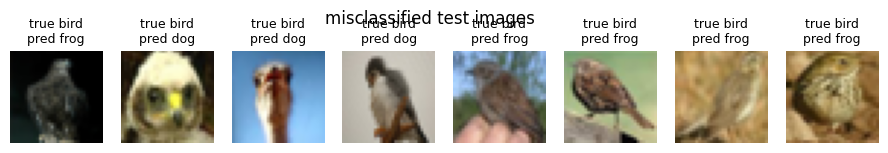

In [19]:
test_ds = test64.dataset
wrong = np.flatnonzero(y_pred != y_true)[:8]
imgs = [test_ds.load_image(int(i)).permute(1, 2, 0).numpy() for i in wrong]
labels = [f"true {classes[y_true[i]]}\npred {classes[y_pred[i]]}" for i in wrong]
print(f"ทายผิด {len(np.flatnonzero(y_pred != y_true))} จาก {len(y_true)} ภาพ")
show_images(np.stack(imgs), labels, n=8, title="misclassified test images")
plt.show()

## ขั้นที่ 9 · บันทึกและโหลดโมเดลที่ fine-tune แล้ว
เก็บ `state_dict` พร้อม**ทุกอย่างที่ต้องใช้ตอน inference**: ชื่อ class, ขนาดภาพ, mean/std ที่ normalize — ไม่งั้นอีกสามเดือนจะไม่รู้ว่าโมเดลนี้ต้องป้อนภาพแบบไหน
โหลดกลับด้วย `build_resnet18_transfer(weights=None)` (โครงเดียวกัน ไม่ต้องดาวน์โหลด ImageNet weights อีก) แล้วตรวจว่าทายเหมือนเดิมทุกภาพ

In [20]:
save_path = f"{tmpdir}/resnet18_cifar3.pt"
torch.save({"state_dict": model.state_dict(), "classes": classes, "size": 64, "mean": IMAGENET_MEAN, "std": IMAGENET_STD}, save_path)
print("บันทึก", save_path, f"({os.path.getsize(save_path) / 1e6:.1f} MB)")

ckpt = torch.load(save_path, weights_only=False)
fresh = build_resnet18_transfer(n_classes=len(ckpt["classes"]), freeze=False, weights=None)   # โครงเดียวกัน น้ำหนักสุ่ม
fresh.load_state_dict(ckpt["state_dict"])
pred_fresh = TorchTrainer(fresh, loss="ce", device=DEVICE).predict_loader(test64)
assert np.array_equal(pred_fresh, y_pred), "โมเดลที่โหลดกลับต้องทายเหมือนเดิมทุกภาพ"
print("โหลดกลับแล้วทายตรงกัน", len(pred_fresh), "ภาพ ✓  classes =", ckpt["classes"], "size =", ckpt["size"])

บันทึก /var/folders/f3/01ng8dg51fv46w7ynfsdt1hc0000gn/T/tmp1mpfwx7r/resnet18_cifar3.pt (44.8 MB)


โหลดกลับแล้วทายตรงกัน 300 ภาพ ✓  classes = ['bird', 'dog', 'frog'] size = 64


## ขั้นที่ 10 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/vision.py และ torch_models.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (Dataset, transforms, ResNet-18 transfer helpers และ EarlyStopping ใน TorchTrainer) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/vision.py และ torch_models.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [21]:
# ทั้ง pipeline ใน 5 บรรทัดด้วยของใน nnlab (ใช้น้ำหนักที่บันทึกไว้ในขั้นที่ 9)
_, _, test_loader, cls = load_cifar3_loaders(batch_size=64, size=64, fast=FAST)
prod = build_resnet18_transfer(n_classes=3, weights=None)
prod.load_state_dict(torch.load(save_path, weights_only=False)["state_dict"])
prod_metrics = TorchTrainer(prod, loss="ce", device=DEVICE).evaluate_loader(test_loader)
print("production pipeline: test accuracy %.3f (ต้องเท่ากับ fine-tuned ด้านบน %.3f)" % (prod_metrics["accuracy"], ft_metrics["accuracy"]))
assert abs(prod_metrics["accuracy"] - ft_metrics["accuracy"]) < 1e-9
print("\nจาก command line:  uv run python scripts/train_transfer.py --mode all --fast   (scratch / head / finetune ในคำสั่งเดียว)")

production pipeline: test accuracy 0.823 (ต้องเท่ากับ fine-tuned ด้านบน 0.823)

จาก command line:  uv run python scripts/train_transfer.py --mode all --fast   (scratch / head / finetune ในคำสั่งเดียว)


## ★ Key Takeaways
- `Dataset` = `__len__` + `__getitem__` ที่อ่านภาพจาก disk เมื่อถูกเรียก; `DataLoader` ประกอบ batch, สับลำดับ และเรียก transform ใหม่ทุก epoch — augmentation จึงเกิดใน `__getitem__`
- transform ของ train (สุ่ม) กับ eval (deterministic) ต้องแยกกัน และ normalize ด้วย mean/std ชุดเดียวกับที่ pretrained model เห็นตอนเทรน
- `model.train()` ต้นทุก epoch และ `model.eval()` + `inference_mode()` ตอนวัด — ลืมแล้วไม่มี error แต่ dropout/BatchNorm ทำงานผิด
- early stopping = จำ `state_dict` ที่ val cost ดีที่สุด แล้วหยุดเมื่อไม่ดีขึ้นติดกัน patience epoch; `TorchTrainer(early_stopping_patience=)` ทำให้พร้อม checkpoint
- transfer learning: freeze (`requires_grad=False`) → แทน head → เทรน head บน feature ที่สกัดครั้งเดียว → fine-tune block ท้ายด้วย lr ต่ำ; ระวัง BatchNorm ที่ยังอัปเดต running stats แม้ freeze แล้ว
- ข้อมูลน้อย (1,200 ภาพ) transfer learning แบบ head-only ชนะ CNN จากศูนย์ทั้ง accuracy และเวลา ด้วย parameter ที่เทรนน้อยกว่าเป็นพันเท่า; fine-tune ให้ผลใกล้เคียงแต่แพงกว่า — ตัดสินด้วย validation และเวลา ไม่ใช่ความรู้สึกว่า "เทรนเยอะกว่าต้องดีกว่า"

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [22]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 13.1 · ปลด freeze สองบล็อกสุดท้าย แล้วนับ parameter ที่เทรนได้
**เป้าหมาย:** เขียน `unfreeze_layer3_4(model)` ที่ใช้ `nnlab.vision.set_trainable` ทำให้เทรนได้เฉพาะ `backbone.layer3`, `backbone.layer4` และ `fc` (ที่เหลือ freeze) แล้วคืนจำนวน parameter ที่เทรนได้ — เทียบกับตารางในขั้นที่ 7(d) ที่ปลดเฉพาะ layer4

**ขั้นตอน**
1. ดูชื่อ parameter ของ ResNet-18 ใน `format_trainable_table(m34)` — ทุกตัวขึ้นต้นด้วย `backbone.<block>` หรือ `fc`
2. เรียก `set_trainable(model, (...))` ด้วย tuple ของ prefix 3 ตัว แล้วคืนค่าที่มันคืนมา (จำนวน parameter ที่ `requires_grad=True`)
3. ทดลองกับ `m34` (โครง ResNet-18 น้ำหนักสุ่ม สร้างให้แล้ว) แล้วพิมพ์ตารางดูว่า layer3 กลายเป็น trainable

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `unfreeze_layer4` ใน `src/nnlab/vision.py` คือตัวอย่างที่ปลดแค่ layer4 — ข้อนี้เพิ่ม prefix อีกหนึ่งตัว
- `set_trainable` ตั้ง `requires_grad=False` ให้ทุกตัวที่ไม่ตรง pattern ด้วย จึงไม่ต้อง freeze เองก่อน
</details>

In [23]:
# --- แบบฝึกหัด 13.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
from nnlab.vision import set_trainable, describe_trainable

def unfreeze_layer3_4(model):
    """ตั้งให้เทรนได้เฉพาะ backbone.layer3, backbone.layer4 และ fc (ที่เหลือ freeze) → คืนจำนวน parameter ที่เทรนได้ (int)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

m34 = build_resnet18_transfer(n_classes=3, freeze=True, weights=None)   # โครง ResNet-18 น้ำหนักสุ่ม (ไม่ต้องดาวน์โหลด) ไว้ทดลอง
# n34 = unfreeze_layer3_4(m34); print(f"{n34:,}"); print(format_trainable_table(m34))

In [24]:
# --- ตรวจคำตอบ 13.1 (รันได้ทันที ไม่ต้องแก้) ---
check_close("13.1 คืน 10,494,979 (layer3 2.10M + layer4 8.39M + fc 1,539)", lambda: unfreeze_layer3_4(m34), 10494979, hint="set_trainable รับ tuple ของ prefix ชื่อ parameter — ดูชื่อจาก model.named_parameters()")
check("13.1 เท่ากับผลรวมจาก describe_trainable ของ module ที่เทรนได้", lambda: unfreeze_layer3_4(m34) == sum(n for _, n, t in describe_trainable(m34) if t), hint="คืนค่าที่ set_trainable คืนมา (ไม่ใช่ None)")
check("13.1 เท่ากับ count_parameters(m34) หลังเรียก", lambda: unfreeze_layer3_4(m34) == count_parameters(m34))
check("13.1 layer2 ยัง freeze ส่วน layer3 / layer4 / fc เทรนได้", lambda: unfreeze_layer3_4(m34) > 0 and not m34.backbone.layer2[0].conv1.weight.requires_grad and m34.backbone.layer3[0].conv1.weight.requires_grad and m34.backbone.layer4[0].conv1.weight.requires_grad and m34.fc.weight.requires_grad, hint="prefix ต้องขึ้นต้นด้วย 'backbone.' เพราะชื่อ parameter คือ backbone.layer3.0.conv1.weight")

⏳ 13.1 คืน 10,494,979 (layer3 2.10M + layer4 8.39M + fc 1,539): ยังไม่ได้ทำ
⏳ 13.1 เท่ากับผลรวมจาก describe_trainable ของ module ที่เทรนได้: ยังไม่ได้ทำ
⏳ 13.1 เท่ากับ count_parameters(m34) หลังเรียก: ยังไม่ได้ทำ
⏳ 13.1 layer2 ยัง freeze ส่วน layer3 / layer4 / fc เทรนได้: ยังไม่ได้ทำ


False

### แบบฝึกหัด 13.2 · class weight สำหรับข้อมูลไม่สมดุล
**เป้าหมาย:** เขียน `class_weights(counts)` ที่ให้ weight แบบ inverse frequency (class เล็กหนักกว่า) normalize ให้ค่าเฉลี่ย = 1 แล้วเขียน `weighted_ce(counts)` ที่คืน `nn.CrossEntropyLoss(weight=...)` — ใช้เมื่อ class หนึ่งมีภาพน้อยกว่าเพื่อน (เช่น frog เหลือ 100 ภาพ)

**ขั้นตอน**
1. คำนวณ `w = 1 / counts` (แปลง counts เป็น float array ก่อน) — class ที่มี 100 ภาพต้องได้ weight มากกว่า class ที่มี 400 ภาพ 4 เท่า
2. หาร `w` ด้วย `w.mean()` ให้ค่าเฉลี่ยเป็น 1 (loss โดยรวมจะไม่เปลี่ยน scale) แล้วคืน array shape `(C,)`
3. `weighted_ce(counts)` แปลง weight เป็น `torch.tensor(..., dtype=torch.float32)` แล้วส่งให้ `nn.CrossEntropyLoss(weight=...)`
4. ทดลองกับ `counts_imb = [400, 100, 400]` — weight ต้องเป็นสัดส่วน 1 : 4 : 1

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `np.asarray(counts, dtype=float)` ก่อนหาร ไม่งั้น `1 / counts` ของ int array ก็ได้ float อยู่แล้วแต่ระวัง list ธรรมดาที่หารไม่ได้
- `nn.CrossEntropyLoss(weight=w)` ต้องการ tensor float32 ยาวเท่าจำนวน class — dtype ต้องตรงกับ logits
</details>

In [25]:
# --- แบบฝึกหัด 13.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def class_weights(counts):
    """counts: จำนวนภาพต่อ class (C,) → weight (C,) แบบ inverse frequency (1/count) ที่ normalize ให้ mean = 1"""
    raise NotImplementedError("ยังไม่ได้ทำ")

def weighted_ce(counts):
    """คืน nn.CrossEntropyLoss ที่ weight = class_weights(counts) เป็น float32 tensor"""
    raise NotImplementedError("ยังไม่ได้ทำ")

counts_imb = np.array([400, 100, 400])   # bird 400, dog 100, frog 400 — class dog เล็กกว่าเพื่อน 4 เท่า
# print(class_weights(counts_imb)); print(weighted_ce(counts_imb).weight)

In [26]:
# --- ตรวจคำตอบ 13.2 (รันได้ทันที ไม่ต้องแก้) ---
lg = torch.tensor([[2.0, 0.5, -1.0], [0.2, 0.1, 0.0], [-1.0, 3.0, 0.5], [0.0, 0.0, 2.0]])   # logits ตัวอย่าง (4, 3)
yy = torch.tensor([0, 1, 1, 2])                                                            # label (4,)

def _manual_weighted():                                   # สูตร weighted mean ที่ torch ใช้: Σ w[y_i]·ℓ_i / Σ w[y_i]
    w = torch.as_tensor(np.asarray(class_weights(counts_imb)), dtype=torch.float32)
    per_sample = torch.nn.functional.cross_entropy(lg, yy, reduction="none")
    return (w[yy] * per_sample).sum() / w[yy].sum()

check_shape("13.2 class_weights shape (3,)", lambda: np.asarray(class_weights(counts_imb)), (3,))
check_close("13.2 mean ของ weight = 1", lambda: float(np.mean(class_weights(counts_imb))), 1.0, hint="หาร weight ด้วยค่าเฉลี่ยของมันเอง")
check_close("13.2 dog (100 ภาพ) หนักกว่า bird (400 ภาพ) 4 เท่า", lambda: float(class_weights(counts_imb)[1] / class_weights(counts_imb)[0]), 4.0, hint="weight ∝ 1 / count")
check("13.2 weight ทุกตัวเป็นบวก และ bird กับ frog (count เท่ากัน) ได้เท่ากัน", lambda: bool(np.all(np.asarray(class_weights(counts_imb)) > 0)) and bool(np.isclose(class_weights(counts_imb)[0], class_weights(counts_imb)[2])))
check("13.2 weighted_ce คืน nn.CrossEntropyLoss ที่มี weight float32 shape (3,)", lambda: isinstance(weighted_ce(counts_imb), nn.CrossEntropyLoss) and weighted_ce(counts_imb).weight is not None and weighted_ce(counts_imb).weight.dtype == torch.float32 and tuple(weighted_ce(counts_imb).weight.shape) == (3,), hint="nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32))")
check("13.2 loss บน batch ตัวอย่างตรงกับสูตร weighted mean ที่คำนวณเอง", lambda: bool(torch.isclose(weighted_ce(counts_imb)(lg, yy), _manual_weighted(), atol=1e-6)), hint="ถ้าไม่ตรง ตรวจว่า weight ที่ส่งให้ loss คือ class_weights(counts) ตัวเดียวกัน")
check("13.2 loss ถ่วงน้ำหนักต่างจาก CrossEntropyLoss ธรรมดา", lambda: not bool(torch.isclose(weighted_ce(counts_imb)(lg, yy), nn.CrossEntropyLoss()(lg, yy))), hint="ถ้าเท่ากัน แสดงว่าลืมส่ง weight= เข้าไป")

⏳ 13.2 class_weights shape (3,): ยังไม่ได้ทำ
⏳ 13.2 mean ของ weight = 1: ยังไม่ได้ทำ
⏳ 13.2 dog (100 ภาพ) หนักกว่า bird (400 ภาพ) 4 เท่า: ยังไม่ได้ทำ
⏳ 13.2 weight ทุกตัวเป็นบวก และ bird กับ frog (count เท่ากัน) ได้เท่ากัน: ยังไม่ได้ทำ
⏳ 13.2 weighted_ce คืน nn.CrossEntropyLoss ที่มี weight float32 shape (3,): ยังไม่ได้ทำ
⏳ 13.2 loss บน batch ตัวอย่างตรงกับสูตร weighted mean ที่คำนวณเอง: ยังไม่ได้ทำ
⏳ 13.2 loss ถ่วงน้ำหนักต่างจาก CrossEntropyLoss ธรรมดา: ยังไม่ได้ทำ


False

### แบบฝึกหัด 13.3 · แบ่ง train / val / test ใหม่แบบ stratified จาก labels.csv
**เป้าหมาย:** เขียน `resplit(table)` ที่ไม่สนคอลัมน์ `split` เดิม แต่แบ่งใหม่จากรายชื่อไฟล์ทั้ง 1,800 ด้วย `nnlab.data.stratified_split` (จาก lab03) สองรอบ แล้วคืน DataFrame ใหม่ที่ `ImageCSVDataset` อ่านได้

**ขั้นตอน**
1. `stratified_split(paths, labels, test_ratio=test_ratio, seed=seed)` คืน `(p_rest, p_test, y_rest, y_test)` — test 1/6 ของ 1,800 = 300 ภาพ (100 ต่อ class)
2. เรียกอีกครั้งกับส่วนที่เหลือด้วย `val_ratio` → `(p_train, p_val, y_train, y_val)` — val 20% ของ 1,500 = 300
3. สร้าง DataFrame 3 ก้อนด้วย `pd.DataFrame({"path": p, "label": y, "split": name})` (name = "train" / "val" / "test") แล้ว `pd.concat(..., ignore_index=True)`
4. ทดลอง: `pd.crosstab(new_df["split"], new_df["label"])` ต้องได้ 400 / 100 / 100 ต่อ class

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `stratified_split` รับ X เป็น array อะไรก็ได้ (ที่นี่คือ array ของ path string) และคืน `X_train, X_test, y_train, y_test` — เรียกครั้งแรกตัด test ครั้งที่สองตัด val
- seed เดียวกันทั้งสองรอบก็ได้ เพราะรอบที่สองสุ่มบนชุดที่ต่างกัน
- `pd.concat([df_train, df_val, df_test], ignore_index=True)` ให้ index เรียงใหม่ 0..1799
</details>

In [27]:
# --- แบบฝึกหัด 13.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
from nnlab.data import stratified_split

def resplit(table, test_ratio=1/6, val_ratio=0.2, seed=463):
    """แบ่ง train/val/test ใหม่แบบ stratified จาก DataFrame (คอลัมน์ path, label) โดยไม่สนคอลัมน์ split เดิม
    คืน DataFrame ใหม่ที่มีคอลัมน์ path, label, split (ค่า 'train' / 'val' / 'test')"""
    paths = table["path"].to_numpy()             # paths: (1800,) path สัมพัทธ์กับ ROOT
    labels = table["label"].to_numpy()           # labels: (1800,) ชื่อ class
    raise NotImplementedError("ยังไม่ได้ทำ")

# new_df = resplit(df); display(pd.crosstab(new_df["split"], new_df["label"], margins=True))

In [28]:
# --- ตรวจคำตอบ 13.3 (รันได้ทันที ไม่ต้องแก้) ---
def _new():
    return resplit(df)

def _balanced():                                          # ทุก class ต้องได้ 400 / 100 / 100 (คลาดเคลื่อนได้ ±2 จากการปัดเศษ)
    ct = pd.crosstab(_new()["split"], _new()["label"])
    return all(abs(ct.loc["train", c] - 400) <= 2 and abs(ct.loc["val", c] - 100) <= 2 and abs(ct.loc["test", c] - 100) <= 2 for c in ct.columns)

def _ds_from_new(split):                                  # เขียน CSV ใหม่ลงโฟลเดอร์ชั่วคราวแล้วให้ ImageCSVDataset อ่าน
    path = os.path.join(tmpdir, "labels_resplit.csv")
    _new().to_csv(path, index=False)
    return ImageCSVDataset(path, root=ROOT, split=split)

check_shape("13.3 DataFrame ใหม่ shape (1800, 3)", lambda: _new(), (1800, 3), hint="concat ทั้ง 3 ส่วนแล้วต้องครบ 1,800 แถว และมีแค่ 3 คอลัมน์ path, label, split")
check("13.3 มีคอลัมน์ path, label, split", lambda: {"path", "label", "split"} <= set(_new().columns))
check("13.3 จำนวนต่อ split = train 1200 / val 300 / test 300", lambda: _new()["split"].value_counts().to_dict() == {"train": 1200, "val": 300, "test": 300}, hint="test_ratio=1/6 ของ 1,800 = 300 แล้ว val_ratio=0.2 ของที่เหลือ 1,500 = 300")
check("13.3 ทุก class ได้ 400 / 100 / 100", _balanced, hint="ต้องใช้ stratified_split (สุ่มภายในแต่ละ class) ทั้งสองรอบ ไม่ใช่สุ่มรวม")
check("13.3 path ครบทุกไฟล์ ไม่ซ้ำ ไม่หาย", lambda: sorted(_new()["path"]) == sorted(df["path"]), hint="ทุกแถวของ df ต้องไปอยู่ split ใดสักอัน พอดีหนึ่งครั้ง")
check("13.3 ImageCSVDataset อ่าน CSV ใหม่ได้: val 300 ภาพ classes เดิม", lambda: len(_ds_from_new("val")) == 300 and _ds_from_new("val").classes == classes, hint="คอลัมน์ต้องชื่อ path, label, split ตรงตัว")

⏳ 13.3 DataFrame ใหม่ shape (1800, 3): ยังไม่ได้ทำ
⏳ 13.3 มีคอลัมน์ path, label, split: ยังไม่ได้ทำ
⏳ 13.3 จำนวนต่อ split = train 1200 / val 300 / test 300: ยังไม่ได้ทำ
⏳ 13.3 ทุก class ได้ 400 / 100 / 100: ยังไม่ได้ทำ
⏳ 13.3 path ครบทุกไฟล์ ไม่ซ้ำ ไม่หาย: ยังไม่ได้ทำ
⏳ 13.3 ImageCSVDataset อ่าน CSV ใหม่ได้: val 300 ภาพ classes เดิม: ยังไม่ได้ทำ


False

### แบบฝึกหัด 13.4 · transfer learning แบบ head-only ที่ขนาดภาพ 32 px
**เป้าหมาย:** เขียน `head_only_val_acc(backbone, size, epochs)` ที่ทำขั้นที่ 7(c) ทั้งหมดในฟังก์ชันเดียว (โหลด loader → สกัด feature → เทรน head) แล้วคืน val accuracy — ใช้ทดลองว่าภาพ 32 px (ต้นฉบับ) เสีย accuracy เท่าไรเทียบกับ 64 px (เกณฑ์ ≥ 0.60)

**ขั้นตอน**
1. `load_cifar3_loaders(batch_size=64, size=size, augment=False, fast=FAST, num_workers=0)` — ใช้ `augment=False` เพื่อให้แต่ละภาพมี feature เดียวที่แน่นอน (ต้องการแค่ train กับ val)
2. `extract_features(backbone, loader, DEVICE)` สำหรับ train และ val → `(features (N, 512), labels (N,))`
3. สร้าง `TorchTrainer(nn.Linear(512, 3), loss="ce", optimizer="adam", lr=1e-3, epochs=epochs, batch_size=64, early_stopping_patience=5, device=DEVICE)` แล้ว `.fit(F_train.numpy(), y_train.numpy(), F_val.numpy(), y_val.numpy())`
4. คืน `float(trainer.history_["val_acc"][-1])`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- cell ของขั้นที่ 7(c) คือคำตอบเกือบทั้งหมด — แค่ห่อเป็นฟังก์ชันที่รับ `size` และตัดส่วน test/copy น้ำหนักออก
- `load_cifar3_loaders` คืน 4 ค่า `(train, val, test, classes)` — ใช้แค่สองตัวแรก
- ที่ 32 px ภาพเล็กกว่าที่ ImageNet คุ้น (224 px) มาก accuracy จึงต่ำกว่า 64 px — นี่คือเหตุผลที่ขั้นที่ 7 เลือก 64
</details>

In [29]:
# --- แบบฝึกหัด 13.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def head_only_val_acc(backbone, size=32, epochs=20):
    """head-only transfer learning ที่ขนาดภาพ size px: loader (augment=False) → extract_features → เทรน nn.Linear(512, 3) → คืน val accuracy สุดท้าย (float)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

backbone32 = build_resnet18_transfer(n_classes=3, freeze=True, weights="DEFAULT")   # backbone แช่แข็ง (น้ำหนักจาก cache ไม่ดาวน์โหลดซ้ำ)
# torch.manual_seed(463); acc32 = head_only_val_acc(backbone32, size=32); print(acc32)

In [30]:
# --- ตรวจคำตอบ 13.4 (รันได้ทันที ไม่ต้องแก้) ---
_acc32 = {}
def _acc():                                               # สกัด feature + เทรน head ครั้งเดียวแล้วจำผลไว้
    if "v" not in _acc32:
        torch.manual_seed(463)
        _acc32["v"] = head_only_val_acc(backbone32, size=32, epochs=20)
    return _acc32["v"]

check("13.4 คืน float ในช่วง [0, 1]", lambda: 0.0 <= float(_acc()) <= 1.0, hint="คืน history_['val_acc'][-1] ของ trainer (ตัวเลขเดียว) ไม่ใช่ list")
check("13.4 val accuracy ที่ 32 px ≥ 0.60", lambda: _acc() >= 0.60, hint="ตรวจว่า loader ของ train ใช้ augment=False และ fit ส่ง val (F_val, y_val) ด้วย ไม่งั้น val_acc จะว่าง")
check("13.4 backbone ยังแช่แข็งหลังเรียก (trainable = 1,539)", lambda: _acc() >= 0 and count_parameters(backbone32) == 1539, hint="อย่าเทรน backbone — extract_features ใช้มันใน eval mode เท่านั้น")
if "v" in _acc32:
    print(f"   head-only val accuracy: 32 px = {_acc32['v']:.3f} | 64 px (ขั้นที่ 7c) = {head.history_['val_acc'][-1]:.3f}")

⏳ 13.4 คืน float ในช่วง [0, 1]: ยังไม่ได้ทำ
⏳ 13.4 val accuracy ที่ 32 px ≥ 0.60: ยังไม่ได้ทำ
⏳ 13.4 backbone ยังแช่แข็งหลังเรียก (trainable = 1,539): ยังไม่ได้ทำ


### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [31]:
summary()

สรุป: PASS 0/20 · FAIL 0 · ยังไม่ได้ทำ 20


{'pass': 0, 'fail': 0, 'todo': 20, 'error': 0}